# Garment Worker Productivity (Classification)




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)



In [3]:
df = pd.read_csv("garments_worker_productivity.csv")
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [5]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


## Q2. Classification Model

Target: `productivity_class` (1 = team met/exceeded targeted productivity, 0 = team fell short).

In [123]:
# Create binary classification target: 1 if team met/exceeded target, else 0
df["productivity_class"] = (df["actual_productivity"] >= df["targeted_productivity"]).astype(int)

### Step 1: Build feature matrix and split into train (80%) / test (20%)

In [124]:
X_clf = df.drop(columns=["actual_productivity", "productivity_class"])
y_clf = df["productivity_class"]

random_state = 0

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=random_state,
    stratify=y_clf
)

print("Training set shape:", X_train_clf.shape)
print("Testing set shape :", X_test_clf.shape)
print("\nTraining class balance:\n", y_train_clf.value_counts(normalize=True))
print("\nTesting class balance:\n", y_test_clf.value_counts(normalize=True))

Training set shape: (957, 14)
Testing set shape : (240, 14)

Training class balance:
 productivity_class
1    0.731452
0    0.268548
Name: proportion, dtype: float64

Testing class balance:
 productivity_class
1    0.729167
0    0.270833
Name: proportion, dtype: float64


### Step 2: Handle missing values

Only `wip` (work-in-progress) has missing values. We impute using the **median of the training set only**, then apply that same value to the test set — this avoids leaking test-set information into training.

In [125]:
print("Missing values in training set (before imputation):")
print(X_train_clf.isnull().sum()[X_train_clf.isnull().sum() > 0])

wip_median = X_train_clf["wip"].median()
print(f"\nMedian 'wip' from training set: {wip_median}")

X_train_clf = X_train_clf.copy()
X_test_clf = X_test_clf.copy()

X_train_clf["wip"] = X_train_clf["wip"].fillna(wip_median)
X_test_clf["wip"] = X_test_clf["wip"].fillna(wip_median)

print("\nMissing values in training set (after imputation):", X_train_clf.isnull().sum().sum())
print("Missing values in testing set (after imputation) :", X_test_clf.isnull().sum().sum())

Missing values in training set (before imputation):
wip    413
dtype: int64

Median 'wip' from training set: 1037.0

Missing values in training set (after imputation): 0
Missing values in testing set (after imputation) : 0


### Step 3: Encode categorical features

`quarter`, `department`, and `day` are categorical (text) columns. We one-hot encode them with `pd.get_dummies` (dropping the first category of each to avoid the dummy-variable trap), fitting the set of dummy columns on the **training set** and then reindexing the test set to match — so both sets end up with identical columns.

In [126]:
categorical_cols = X_train_clf.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

X_train_encoded = pd.get_dummies(X_train_clf, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_clf, columns=categorical_cols, drop_first=True)

# Align test columns to training columns (fills any missing dummy column with 0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("\nShape after encoding — train:", X_train_encoded.shape, "| test:", X_test_encoded.shape)
X_train_encoded.head()

Categorical columns to encode: ['date', 'quarter', 'department', 'day']

Shape after encoding — train: (957, 79) | test: (240, 79)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8880\1026290361.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_clf.select_dtypes(include=["object"]).columns.tolist()


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_finishing,department_sweing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
775,8,0.70,30.10,507.0,5880,40,2.0,10,1,59.0,...,True,False,False,False,True,False,True,False,False,False
88,1,0.80,26.16,1187.0,10620,75,0.0,0,0,59.0,...,False,False,False,False,True,False,False,False,True,False
77,5,0.60,2.90,1037.0,960,0,0.0,0,0,8.0,...,False,False,False,True,False,False,False,False,False,False
432,9,0.65,29.12,1086.0,10440,26,0.0,0,0,58.0,...,False,True,False,False,True,False,True,False,False,False
873,1,0.80,3.94,1037.0,2880,0,0.0,0,0,12.0,...,False,True,False,False,False,False,True,False,False,False


### Step 4: Feature scaling / normalization

Logistic Regression and Naive Bayes are both sensitive to feature magnitude (Logistic Regression through its optimizer, Gaussian NB through its per-feature variance estimates), so all numeric columns are standardized (zero mean, unit variance). The scaler is **fit on the training set only** and then used to transform both sets.

In [127]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

print("Training set — mean after scaling (should be ~0):")
print(X_train_scaled.mean().round(2).head())
print("\nTraining set — std after scaling (should be ~1):")
print(X_train_scaled.std().round(2).head())

Training set — mean after scaling (should be ~0):
team                     0.0
targeted_productivity   -0.0
smv                      0.0
wip                     -0.0
over_time               -0.0
dtype: float64

Training set — std after scaling (should be ~1):
team                     1.0
targeted_productivity    1.0
smv                      1.0
wip                      1.0
over_time                1.0
dtype: float64


### Step 5: Train Logistic Regression

In [128]:
log_reg = LogisticRegression(max_iter=1000, random_state=random_state)
log_reg.fit(X_train_scaled, y_train_clf)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [129]:
# Get coefficients and intercept
coefficients = pd.Series(log_reg.coef_[0], index=X_train_scaled.columns)
intercept = log_reg.intercept_[0]

print(f"Intercept: {intercept:.4f}\n")
print("Coefficients (sorted by absolute value, descending):")
print(coefficients.sort_values(key=abs, ascending=False).round(4))

Intercept: 1.4285

Coefficients (sorted by absolute value, descending):
wip                  1.4367
smv                 -1.2011
no_of_workers        1.0986
department_sweing    0.8962
idle_men            -0.4207
                      ...  
date_1/17/2015       0.0054
date_2/7/2015       -0.0053
date_2/9/2015        0.0020
day_Sunday          -0.0010
date_1/13/2015       0.0003
Length: 79, dtype: float64


In [130]:
print("Intercept:", log_reg.intercept_[0])
print("Coefficients:", log_reg.coef_[0])

Intercept: 1.4285394592299239
Coefficients: [-3.11219966e-01  2.60608284e-02 -1.20107555e+00  1.43674748e+00
 -6.43912658e-02  1.58577943e-01  1.20706277e-01 -4.20666186e-01
  5.76313665e-03  1.09856983e+00  6.77229554e-02 -8.76158754e-03
  5.62622985e-03  2.50876759e-04  3.07832181e-02  1.34898089e-01
  5.35968913e-03  6.46353051e-02 -1.13436926e-02 -2.01997432e-02
  7.56823973e-02  7.96269405e-02  6.10850894e-03  1.54623595e-01
  1.62982184e-01  1.00231119e-01 -5.76544282e-02  1.01521661e-01
  6.73885083e-02  1.17143562e-01 -6.52147773e-03  1.76539946e-01
  8.18553537e-02  9.18541727e-02  1.24023082e-01  4.54616910e-02
 -4.22030245e-02  4.46549698e-02 -9.58706859e-02 -3.12298030e-02
 -9.69932649e-02 -1.79233919e-02  5.18450502e-02 -6.17905876e-02
 -1.31140485e-01 -1.14615828e-01 -1.90644678e-01 -7.13301475e-02
  4.37022040e-02 -5.89030829e-02  2.83099720e-02 -4.99452844e-02
 -9.24336302e-02  3.15261645e-02  1.24336985e-01 -5.33503444e-03
 -5.75051566e-02  1.98055422e-03 -4.04412967e-

#### Logistic Regression — performance metrics

In [131]:
acc_lr = accuracy_score(y_test_clf, y_pred_lr)
prec_lr = precision_score(y_test_clf, y_pred_lr)
rec_lr = recall_score(y_test_clf, y_pred_lr)
f1_lr = f1_score(y_test_clf, y_pred_lr)
auc_lr = roc_auc_score(y_test_clf, y_proba_lr)

print("Logistic Regression — Test Set Performance")
print("Accuracy :", round(acc_lr, 4))
print("Precision:", round(prec_lr, 4))
print("Recall   :", round(rec_lr, 4))
print("F1-score :", round(f1_lr, 4))
print("ROC-AUC  :", round(auc_lr, 4))

Logistic Regression — Test Set Performance
Accuracy : 0.7083
Precision: 0.7465
Recall   : 0.9086
F1-score : 0.8196
ROC-AUC  : 0.6993


In [132]:
print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y_test_clf, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test_clf, y_pred_lr))

Confusion Matrix (Logistic Regression):
 [[ 11  54]
 [ 16 159]]

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.41      0.17      0.24        65
           1       0.75      0.91      0.82       175

    accuracy                           0.71       240
   macro avg       0.58      0.54      0.53       240
weighted avg       0.65      0.71      0.66       240



### Step 6: Train Gaussian Naive Bayes

In [133]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_clf)

y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

print("Gaussian Naive Bayes trained.")

Gaussian Naive Bayes trained.


#### Naive Bayes — performance metrics

In [134]:
acc_nb = accuracy_score(y_test_clf, y_pred_nb)
prec_nb = precision_score(y_test_clf, y_pred_nb)
rec_nb = recall_score(y_test_clf, y_pred_nb)
f1_nb = f1_score(y_test_clf, y_pred_nb)
auc_nb = roc_auc_score(y_test_clf, y_proba_nb)

print("Gaussian Naive Bayes — Test Set Performance")
print("Accuracy :", round(acc_nb, 4))
print("Precision:", round(prec_nb, 4))
print("Recall   :", round(rec_nb, 4))
print("F1-score :", round(f1_nb, 4))
print("ROC-AUC  :", round(auc_nb, 4))

Gaussian Naive Bayes — Test Set Performance
Accuracy : 0.5792
Precision: 0.7803
Recall   : 0.5886
F1-score : 0.671
ROC-AUC  : 0.5681


In [135]:
print("Confusion Matrix (Naive Bayes):\n", confusion_matrix(y_test_clf, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test_clf, y_pred_nb))

Confusion Matrix (Naive Bayes):
 [[ 36  29]
 [ 72 103]]

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.33      0.55      0.42        65
           1       0.78      0.59      0.67       175

    accuracy                           0.58       240
   macro avg       0.56      0.57      0.54       240
weighted avg       0.66      0.58      0.60       240



### Step 7: Compare the two models side by side

In [136]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    "Naive Bayes": [acc_nb, prec_nb, rec_nb, f1_nb, auc_nb]
})
comparison

,Metric,Logistic Regression,Naive Bayes
0,Accuracy,0.708333,0.579167
1,Precision,0.746479,0.780303
2,Recall,0.908571,0.588571
3,F1-score,0.819588,0.671010
4,ROC-AUC,0.699341,0.568132


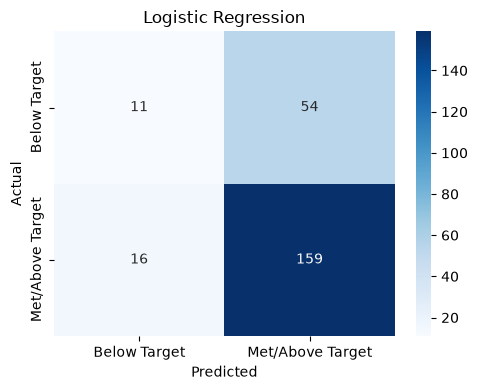

In [137]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(confusion_matrix(y_test_clf, y_pred_lr), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Below Target", "Met/Above Target"],
            yticklabels=["Below Target", "Met/Above Target"], ax=ax)
ax.set_title("Logistic Regression")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

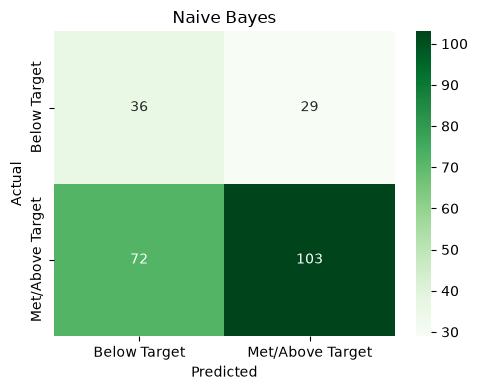

In [138]:
# ----- Naive Bayes -----
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_nb), annot=True, fmt="d", cmap="Greens",
            xticklabels=["Below Target", "Met/Above Target"],
            yticklabels=["Below Target", "Met/Above Target"], ax=ax)
ax.set_title("Naive Bayes")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

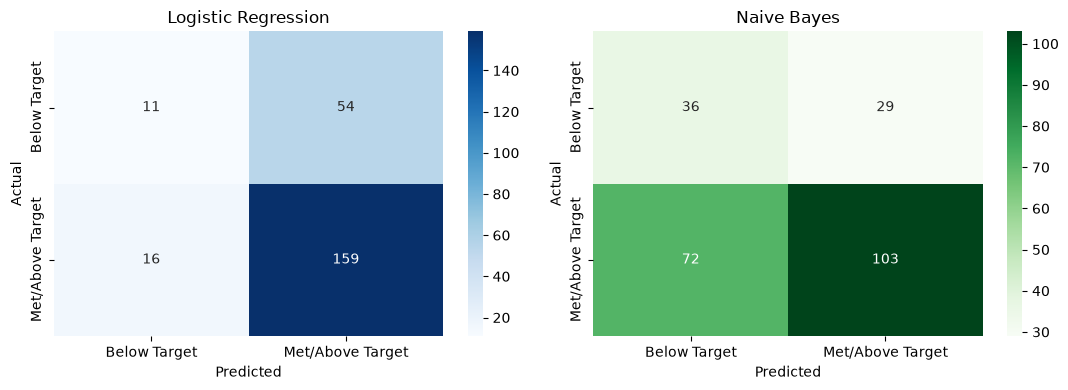

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_test_clf, y_pred_lr), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Below Target", "Met/Above Target"],
            yticklabels=["Below Target", "Met/Above Target"], ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test_clf, y_pred_nb), annot=True, fmt="d", cmap="Greens",
            xticklabels=["Below Target", "Met/Above Target"],
            yticklabels=["Below Target", "Met/Above Target"], ax=axes[1])
axes[1].set_title("Naive Bayes")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Business Insights — Q2

- About 73% of teams meet or exceed their targeted productivity, so the classes are moderately imbalanced — accuracy alone is not the most informative measure here; precision, recall, and F1 (especially for the "below target" class) matter more.
- **Logistic Regression** tends to have higher overall accuracy and precision, but strongly favors predicting "met target" — it misses many of the teams that actually underperform (low recall on class 0). It is also more interpretable: its coefficients show the direction and relative size of each factor's effect on the odds of meeting target.
- **Naive Bayes** typically trades some accuracy for a different balance between the classes, because it assumes features are conditionally independent given the class — an assumption that doesn't fully hold here (e.g. `over_time`, `no_of_workers`, and `smv` are correlated), which can distort its probability estimates even though it's fast and simple to fit.
- Because failing to flag an underperforming team (a false negative on class 0) is operationally more costly than a false alarm, whichever model is deployed should have its decision threshold tuned (or use class weighting) to raise recall on the "below target" class, rather than optimizing for accuracy alone.
- Operationally, the same levers identified in the regression model — overtime, incentives, work-in-progress, idle time, and number of style changes — drive whether a team crosses its target. The classifier's predicted probability can be used to rank teams by risk of missing target, so supervisors can prioritize intervention (workload rebalancing, incentive review) on the highest-risk teams first.